# Shape and Symmetry of 2D Shapes in images

**Supervisor: Wolfram**

**Module: PHY3147**

**Student Number:  730028919**

Risk Assessment: [Risk Assessment](Risk.pdf)


# Table of Contents

1. Experiment Outline: General outline of the goals for the experiment.
    - 1.1 Overall aims
    - 1.2 Key expectations of experiment
    - 1.3 Reading Summary
    - 1.4 Plan Outline

2. Theory: A historical backgorund and explanation of the equations which will be used during the experiment.

    - 2.1 Image Moments overview
    - 2.2 Shape Overview
    - 2.3 Theoretical expectations


3. Details for each session & meeting summaries: Section devoted to going over what the supervisor for this experiment spoke about during each of the meetings as well as the work which was done during each of the sessions with dates

    - Week
    - Meetings

4. Code Details: outline of the folder structure and the folders and files contained along with a description of them


5. Creation of the Binary Image: a section focused on making the images binary and the results of that work.

6. Quantifying Symmetry: A section focused on the different methods of symmetry quanification, comparison of these methods will also be done in this section.

    - 6.1 Overview of methods
    - 6.2 Outline of key details
    - 6.3 Method 1: Calculation of area and rotation of image
        - 6.3.1 Key details
        - 6.3.2 Analysis of findings, Method 1
            - 6.3.2.1 Overview
            - 6.3.2.2 Figures
            - 6.3.2.3 Test image
            - 6.3.2.4 Other images
        - 6.4 Method 2: Calculation of Hu moments
            - 6.4.1 Outline:
            - 6.4.2 Analysis of findings: Method 2
                - 6.4.2.1 Overview
                - 6.4.2.2 Figures
                - 6.4.2.3 Test image
                - 6.4.2.4 Other images

7. Quantifying Shape: A section focused on quantifying the shape of different objects in images.

8. Handling error: section focusing on how error will be handled in the experiment

    - 8.1 Key Sources of error
        - 8.1.1 Floating-point rounding errors
        - 8.1.2 Gaps in binary image
        - 8.1.3 Overfilling
        - 8.1.4 General errors in code both in code an method

9. Bibliography: used for storing all important citations so that claims are supported

# 1. Experiment outline

## 1.1 Overall Aim: 

In this project, you will aim to explore the use of image moments for quantifying the shape and symmetry of objects
of your choice.

## 1.2 Key expectations of experiment: 

1. To create and/or identify a set of images, both real and simulated, which can be used to quantify the symmetry of an object.

2. Convert the images into a binary format

3. Develop code that from this may calculate image moments from the images selected

4. Test code to demonstrate what each image moment tells you about the objects within the image.

5. Test the code for how well it quantifies both shape and symmetry

6. Extensions:
    - Compare the usage of Hu moments to the usage of raw image moments of order 0, for the task of quantifying symmetry, investigating the benefits and drawbacks of each method.

    - Investigate into image classification with the use of image moments in order to quantify the shape of objects in images

    - Investigation of both the use of image moments calculated using the cv2 library and custom functions to provide a potential success criteria 

    - produce image moments for images with varying intensities and look into how these images may be handled

## 1.3 Reading Summary

There was a large amount of papers which referenced different topics each relevant to the project in different ways.

Some papers help describe the purpose of Hu moments and how they can be used in investigation to find different qualities about images. [1],[2]

Some provided an insight into how error may be handled in the experiment. [3], [6]

Some focused mainly on symmetry and provided an understanding of what image moments can be used for to help find symmetry lines. [5], [8]

Some focused on the pracical applications of the image moments. [4], [7]

All of these provide better understanding of the purpose of image moments and how goals can be achieved efficiently and accurately. In addition having an understanding of how they may provide utility in the real world, allows for better extensions to be created.

## 1.4 Plan Outline

There is a large amount of literature on the issue with can provide an insight into how this experiment can be performed.

Image moments can be used in both biology and physics research as they can be used to detect disorders such as schizophrenia by comparing the symmetry between hemispheres of the brain [1]. In physics however they can be used in order to detect the similarities between crystal structures[2].

Due to this, an investigation of both biological and physical images would be fitting and so a bone and a snowflake will be used. Due to this it is important to use a large number of different types of images with different features. 

It is clear that from the literature Hu moments are the primary option for symmetry comparison [3] and so to find a so why this is, and to better explain and potentially quantify these differences as clear findings.

It is likely the lines of symmetry for the objects can be obtained by calculating a symmetry score and then looking for the minima of the graphs which should reveal a large amount of insight into the shape. In addition by comparing how each graph differes it is likely that the data would be best presented in graphs as this would allow for clear differences to be outlined.

In addition there's a large number of descriptions of shape available, as such it is possible to create a table of these findings and present them in one large set. This will allow for all the data to be presented together.

Finally it is possible to perform image classification using image moments [4], this will be done by finding the image moments for different objects and using them as a type of image and then investigating into a set of new images to see if they can be classified as the correct images.

If further extensions can be found along the way, they may be investigated when if possible.

# 2 Theory


## 2.1 Image Moments overview

During this experiment, it is important to use image moments to be able to quantify both shape and symmetry. To do this it is important to define the image moment.

the image moment formula can be defined as:

$$ M_{ij} = \sum_{x}\sum_{y} x^i y^j I(x,y) $$

**Eq.(1). Raw image moments**

where the sum of i and j denote the order for the moment.

For a continuous distribution it may be written as a summation. However for the sake of this investigation, this will not be needed.


The eq(1) can be described as a raw image moment and can be used for the sake of calculating the area of an object in an image, $M_{00}$, or the calculation of the centroid:


$$ \left(\bar{x},\bar{y}\right)= \left(\frac{M_{10}}{M_{00}}, \frac{M_{01}}{M_{00}}\right) $$

**Eq.(2) Centroid calculation**

The centroid can be thought of in the same way as the centre of mass.

For orders greater than 1, central order moments will be used as they are translationally invariant and will provide insight into symmetry for Hu moments as well as ideas related to shape.

$$\mu_{pq} = \sum_{m}^{p}\sum_{m}^{q}(x-\bar{x})^{p}(y - \bar{y})^{q}f(x,y)$$

**Eq.(3) Central image moments**

$f(x,y)$ in this case would be the intensity of the pixels.

Eq.(3) can be thought of as being derived from statistics with the concept of central moments describing skew as well as variance of a distribution. These concepts can be used for a description of shape.

For Hu moments the following equation is used where the $\nu$ shown is the normalised moments

$$
\eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^{1 + \frac{p + q}{2}}}
$$
**Eq.(4) normalised moments**

$$
\begin{aligned}
I_1 &= \eta_{20} + \eta_{02} \\
I_2 &= (\eta_{20} - \eta_{02})^2 + 4\eta_{11}^2 \\
I_3 &= (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2 \\
I_4 &= (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2 \\
I_5 &= (\eta_{30} - 3\eta_{12})(\eta_{30} + \eta_{12})\big[(\eta_{30} + \eta_{12})^2 - 3(\eta_{21} + \eta_{03})^2\big] \\
&\quad + (3\eta_{21} - \eta_{03})(\eta_{21} + \eta_{03})\big[3(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2\big] \\
I_6 &= (\eta_{20} - \eta_{02})\big[(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2\big] + 4\eta_{11}(\eta_{30} + \eta_{12})(\eta_{21} + \eta_{03}) \\
I_7 &= (3\eta_{21} - \eta_{03})(\eta_{30} + \eta_{12})\big[(\eta_{30} + \eta_{12})^2 - 3(\eta_{21} + \eta_{03})^2\big] \\
&\quad - (\eta_{30} - 3\eta_{12})(\eta_{21} + \eta_{03})\big[3(\eta_{30} + \eta_{12})^2 - (\eta_{21} + \eta_{03})^2\big]
\end{aligned}
$$
**Eq.(5) Hu moments**

These come together to become the freature vector.

$$V = [I_1, I_2,..., I_7]$$

**Eq.(6). Feature vector**

For an investigation of symmetry, the concept of a symmetry score will be used where the minima will describe the lines of symmetry.

For the first method, a simplistic comparison of areas will be used. Between the left and the right sides. For the Hu moments, they are compared between the left and right sides also.

$$ Score = \frac{Moment^{Left} - Moment^{Right}}{Moment^{Left} + Moment^{Right}}$$

**Eq.(7). Symmetry Score calculation**

For this the moment in queston changes form raw zeroth order to Hu moments

## 2.2 Shape Overview

Eccentricity is is a description of how elongated a shape is, it can describe how much it deviates from being circular.

$$e = \sqrt{1 - {\frac{\lambda_2}{\lambda_1}}}$$

**Eq.(8) Eccentricity**

here, lambda are the eigenvalues derived from the following covariance matrix:

$$C = \frac{1}{\mu_{00}}
\begin{bmatrix}
\mu_{20} & \mu_{11} \\
\mu_{11} & \mu_{02}
\end{bmatrix}$$

**Eq.(9) Covariance matrix**

Orientation can be used to describe the angle for which the object major axis is relative to the referance axis.

$$ \theta = \frac{1}{2} \arctan{\frac{2\mu_{11}}{\mu_{20} - \mu_{02}}}$$

**Eq.(10) orientation**

skewness can be described as being how asymmetric an object within an image is, with positive values denoting right skewness and negative left.

$$
S_x = \frac{\mu_{30}}{\mu_{20}^{3/2}}, 
\qquad
S_y = \frac{\mu_{03}}{\mu_{02}^{3/2}}
$$
**Eq.(11). Skewness**


## 2.3 Theoretical Expectations

During the experiment it is required to find Hu moments and raw moments for symmetry. To show that these work as expected, and to provide success criteria. The following calculation was performed by hand.

Given a horizontal line of length 5, the value for the raw image moments should be:

$$ M_{00} = 5 \space \& \space M_{10} = 20 \space \& \space M_{01} = 10$$

For the Hu moments the values found were that only $I_1$ and $I_2$ have non-zero values.

$$ I_{0} = 0.4 \space \& \space I_{1} = 0.16 $$

To ensure that the findings in the experiment are correct these calculations can be performed. If accurate, similar values should be found.

In [2]:
# code performing the needed calculations for the Theory.
import cv2 as cv
import Img_moments as IM
import numpy as np

#image
img = np.zeros((5, 10), dtype=np.uint8)

# adds in the horizontal line
img[2, 2:7] = 1


# shows image
print("Image array:")
print(img)

# Calculate image moments
M = [IM.Raw_Img_Moment(img,0,0), 
    IM.Raw_Img_Moment(img,1,0), 
    IM.Raw_Img_Moment(img,0,1)]

# Display some of the moments
print("\nCalculated Moments:")
print(f"M_00: {M[0]}, M_10: {M[1]}, M_01: {M[2]}")

cx, cy = IM.Centroid(img)

I = IM.Hu_Moments(img, cx, cy)

print(f"I_1: {I[0]}, I_2: {I[1]}, \n I_3: {I[2]}, I_4: {I[3]}, \n I_5: {I[4]}, I_6: {I[5]}, \n I_7: {I[6]}")

Image array:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

Calculated Moments:
M_00: 5, M_10: 20, M_01: 10
I_1: 0.4, I_2: 0.16000000000000003, 
 I_3: 0.0, I_4: 0.0, 
 I_5: 0.0, I_6: 0.0, 
 I_7: 0.0


Clearly these findings are as expected and so these calculations are likely to be correct.

## 3 Details for each sessions & meeting summaries

Details are set to the week for which the project began, the week for which the project was chosen has been excluded due to a lack of work being done during that period.

## Week 1:

#### Session 1, Date: 26/09/25

**Session aim/goal:** Look into experiment and get an idea of what to do

- Spoke to Supervisor about the project:

    #### Meeting 1:

    - The images used could either be simulated or real

    - The real images are unlikely to require noise to be added

- Investigated which images would work for the experiment and created a overall plan for the experiment.

- looked into cv2 and what it does

**Outcome:** Went well and found a number of resources which may be helpful in future investigation. Also defined the scope of the project

**Plan:** Potentially work next session to make binary images

## Week 2:

#### Session 2, Date: 29/09/25

**Session aim/goal:** To produce clear binary images which can be used for later calculations and to look into how things may differ for different images

- Created binary image from the image chosen, image of a starfish.

- Began to code and investigated into cv2 and how it is used.

    - Code for the binary conversion, also called threasholding.

- Found the binary conversion is difficult for images without clear background and foreground

    - Clear being described as images that have a large difference between the colours used in the backround and foreground such that the threasholding done to the images produces white pixels over the object of interest.

- To create binary images, of images without clear background and foreground, it would require the use of machine learning which is beyond the scope of the experiment.

**Outcome:** Produced binary image for starfish however it is clear that some issues may arise for more complex images as such standards surrounding the image selection must be set

**Plan:** Create the previously stated standards and collect images which meet them.

#### Session 3, Date: 03/10/25

**Session aim/goal:** Choose more images to use, look deeper into image moments

- Chose to use images with a clear background as previous images used showed difficulty being converted into binary images. See Fig.().

- Investigated further into image moments and their purpose finding sources which may be useful in future investigations

- Decided to both create code for the calculation of image moments and used code from cv2 for the purposes of comparing the two methods.

    - Provides a clear success criteria.

**Outcome:** aims met as expected and exceeded with the use of two sets of code to perform the same function in different ways

**Plan:** Mention issues with starfish and how the problem was solved to supervisor and work on improving code readability
    
#### Session 4, Date: 03/10/25

**Session aim/goal:** refine code

- Code is refined to improve readability.

- Asked demonstaror for advice for the starfish image which also showed issues related to the binary conversion.

    #### Meeting 2:

    - The images produced should likely be compared with those produced using the Fiji software as they may provide results that can be compared against our found binary images

    - The real images may be produced using AI however noise is still not required for those classified as "real"

    - Updates provided to supervisor on the current code as well as the next steps: we looked for images that would be able to work given the starfish showed clear issues due to both the shadow as well as the smaller objects in the background.


**Outcome:** partially successful as although github showed issues when setting up, overall code saved there as expected

**Plan:** move the rest of code onto github and fix issues with github on lab partners computer


## Week 3:

#### Session 5, Date: 06/10/25

**Session aim/goal:** move the rest of code onto github and fix issues with github on lab partners computer, reformat code for the image moment calculation

- Moved majority of code onto Github in order to better track codes development over time and to create a back up of code in case of damage to hardware.

- Began to look further into the origin of image moments to help create code related to the image moment calculation and calculation of the centroid.

- Issues with Github begin with branch related issue needed fixing

**Outcome:** performed as expected however still need to finish code related to image moment calculation so that errors don't show when handling image and centroid calculation must be completed

**Plan:** create code for the centroid and discuss current work with supervisor

#### Session 6, Date: 10/10/25

**Session aim/goal:** create centroid code and work on lab book format

- Asked demonstrater about the expectations surrounding the lab book

    #### Meeting 3:

    - Supervisor explained that the standards the lab book is to be held to.

    - Lab book is to be given in with the risk assessment attached

    - Lab book should have dated entries which should be done using hashes from Github.

    - Discussed the current idea of how to quantify symmetry, through the use of image moments and rotation of the image

- Updated lab book to attempt to meet expected standard

- Created code for the centroid

- Began creating code for rotation of the image about the centroid

**Outcome:** expectations exceeded as code was completed and created code which rotates the image about the centroid, which was a major step in completing the first symmetry quantifying method

**Plan:** work further on this method to ensure that the lines of symmetry can be produced and work further on lab book's presentation

#### Session 7, Date: 10/10/25

**Session aim/goal:**  Fix the issue with github so that code sharing can be done

- Issues with Github persist as branches refuse to merge

- Did work related to the centroid calculation

- Reformatted code to better fit expectations

**Outcome:**  lab partner needs to complete their section of code before further work may be done

**Plan:** work based off of laptop and create a new repo after work has been completed so that issues related to github may not persist

## Week 4:

#### Session 8, Date: 13/10/25

**Session aim/goal:** reformat code on laptop directly

- Waited for lab partner's section of code

- Chose to leave code on github and work directly from laptop, remotely store work, until code is complete to prevent potential issues related to github requiring git commands for the merges

- Reformatted code again

**Outcome:** code is more generalised now such that the program is more consistent with goals

**Plan:** meet with supervisor for further advice

#### Session 9, Date: 17/10/25 

**Session aim/goal:**  meet with supervisor and ask him for advice on supervisor

-  Met with supervisor:

    #### Meeting 4:

    - Advised to look into Hu moments as a potential method of symmetry calculation.

    - Before the presentation it is important to look into producing clear results such that comparisons for the values found may be made.

    - For the presentation it is important to discuss how images are represented within the code such that then the method used for the centroid calculations can be better understood by the audience.

    - Ensure the work done is able to show that the task was understood such that the audience viewing it may understand during the presentation.

    - Some images show clear issues when rotated as they go outside the limits of the picture, to avoid this issue it is important to crop the image.
        - To do this correctly ensure that the minimum virtical and horizontal distance between the top of the image and the side of the image is found and then set the new boundaries in the 4 directions to these lengths, this sets the centroid at the center of the image.

    - Some images show black spots where they should be completely intense, to fix this use the cv2 fill function.

    - The use of the conture function may provide an idea for the centroid for images that aren't filled, i.e just lines, however they may not provide a correct idea of filled ones due to the fact that the image is being considered in totality but only it's outline using this method.

    - Unit tests are required as they will allow for a the method to be made clear and to ensure the method works as expected.


**Outcome:** ideas of what to do have been gained, do them.

**Plan:**  full fill the outlines given by supervisor

#### Session 10, Date: 17/10/25

**Session aim/goal:**  produce code for recentering

- With the method already outlined, worked to produce the code for recentering the image as well as calculate the "Symmetry Score" for the image.

- Decided to compare the use of the first method and the use fo Hu moments to better gain an idea of the costs and benefits of each method such that further insight can be gained.

**Outcome:** met goals as expected

**Plan:** work on presentation and produce graphs to assist in this

## Week 5:

#### Session 11, Date: 20/10/25

**Session aim/goal:** work on presentation and produce graphs to assist in this

- Worked on the presentation as well as produced graphs which would help make key points during the presentation clear

    - Symmetry core against angle in degrees for each rotation to see how far offset 

- Met with supervisor again to ensure that work is as expected and aims are accurate to what should be done.

    #### Meeting 5:

    - Obtianed good images which have a clear background and foreground

    - Centroid calculation, code has been produced

    - Rotate image about the centroid after image has been recentered with centroid at the centre.

    - Produce key visualisations and find insights to present during presentation


- Further investigation done to better understand the use of 2nd and 3rd order moments

- Produced code that would calculate central order moments given that the raw moments at these orders are of little use

**Outcome:** met expectations and exceeded them in some areas

**Plan:** Work further on presentation and format code to better meet lab book requirements

#### Session 12, Date: 24/10/25

- Missed due being sick however work on the presentation was done!

#### Session 13, Date: 24/10/25

- Presentation was at this time and so no work done during this time

## Week 6:

#### Session 14, Date: 27/10/25

**Session aim/goal:** Work further on presentation and format code to better meet lab book requirements

- Went onto further format the code to better fit the expectations of the lab book

- Waited for lab partner to code their section of work

**Outcome:** somewhat met however need to work further to complete goals for lab book

**Plan:** work more on lab book

#### Session 15, Date: 31/10/25

**Session aim/goal:** work more on lab book and wait for code from lab partner

- Asked supervisor about the expectations surrounding the lab book again.

    #### Meeting 6:

    - Contents table should not include details about where the data is stored,

    - key details about what each image is should be used to make it clear to the reader their importance.

    - Theory should include details related to the by hand sanity check for the centroid and image moments calculations.

**Outcome:** couldn't yet meet goal however code was further reformatted

**Plan:** finish code format if possible so no further large changes to structure are needed

#### Session 16, Date: 31/10/25

**Session aim/goal:** finish code format if possible so no further large changes to structure are needed

- Worked further to format the code to better align with lab book expectations.

- Worked to investigate into Hu moments further

**Outcome:** meet some expectations however code still needs some reformatting but supplemented missed work with further investigation into Hu moments

**Plan:** To investigate into Hu moments and create code that calculates them. If possible look further into how shape is quantified

## Week 7:

**Session aim/goal:** To investigate into Hu moments and create code that calculates them. If possible look further into how shape is quantified

- Hu moments tell you about shape and symmetry and how far away specific ones are from zero, the more asymmetric the object.

- Flipping the image about the y axis can tell us to what side the image is skewed if the value of specific Hu moments changes.

- Asked supervisor if the scope of project is enough and if the lab book is of the level it needs to be

#### Meeting 7:

- We need to have results and we need to have those results checked.

    - We need to use simulated images that can help to sanity check the method used.

    - This allows us to say if the method is good or bad.


- created a simulated image and then produced code that would run said code as a sanity check.

- check open cv floodfill, imfill for matlab.


**Outcome:** created code that produces Hu moments and used them to create the second method of symmetry quantification.

**Plan:** create code which performs the calculation for shape of the image.

#### Week 8

#### Session 17, Date: 07/11/25

**Session aim/goal:** During this session code should be checked again as calculation for Hu moments doesn't work as expected

- Worked will lab partner to try and fix bugs in their code

- Worked further on method 1 for symmetry analysis such that code produces plots as needed.

**Outcome:** somewhat worked, more plots for different images must be completed

**Plan:** Create graphs from both methods for symmetry and further investigate shape


#### Session 18, Date: 10/11/25

**Session aim/goal:** To complete the experiment.

- lab partner has shared code with me which should allow for the error to be fixed.

- will compelete the method 1 and then extrapolate this finding to Hu moments which will solve the problem.

- meeting with supervisor

#### Meeting 8:

- create a table for the areas using the raw moments and compare them with lab partner's values and these should give similar results if accurate.

- use Hu moments to complete shape matching for an investigation of shape.

- use all 7 Hu moments to compute the symmetry scores, this can be done with the same equation as for the areas just replacing the areas with the Hu moment vectors.

- Ignore the Method 1 as it seems to not be very advanced and so we may want to simply look into Hu moments instead of area and Hu moments.


**Outcome:** Produced the required code to some extent and although method 1 was stated to be unimportant as it didn't take too long to create, and so both the Hu moment and Raw moment codes will be used to analyse symmetry. Shape still illudes us

**Plan:** look into shape more to better understand what is required for the shape analysis, create a collection of images which can be converted into binary such that then Hu moments can be produced from them and then compared with other images for the sake of classification.



#### Session 19, Date: 12/11/25

**Session aim/goal:** complete standard experiment as best possible

- created a table of feature data

- created visualisations for both methods required

- finished the basic expectations for the experiment

**Outcome:** completed standard experiment

**Plan:** more extensions may be looked into as comparison of different methods although good may not meet the full scope required for experiment

## 4 Code Details

1. [Main.ipynb:](Main.ipynb)  The main code file which will take in th needed data and return the expected outputs

2. [Helpers.py:](Helpers.py) A file which will contain functions that are used repeatedly throughout different files

3. [Data:](Data) A folder containing all data to be used for the project.

    1. [Raw:](Data\Raw) A folder containing all the unprocessed data.
    2. [Conv:](Data\Converted) A folder containing all the completely processed data.
    3. [Symm:](Data\Symm) A folder containing all the binary images with the lines of symmetry added.
    4. [Plots:](Data\Plots) A folder containing all the related plots for symmetry score against angle in degrees relative to the vertical axis

4. [img_moments.py](Img_moments.py) A file for all the image moment related code

5. [Plotting.py](Plotting.py) A file for creating all the important plots

6. [Score.py](Score.py) A file for performing the important symmetry score calculations

7. [Binary.py](Binary.py) A file for performing all the related binary convertions such that images may have key analysis performed on it

In [3]:
# the common libraries used in the previous code version.
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt


# custom libraries made to keep code clean and up to standard
import Helpers as H
import Score as S
import Binary as B
import Plotting as P


#ensures we are in the correct location
os.chdir(r"C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs")

# 5 Creation of the binary image

## Outline:

- select images which are appropiate for conversion

- use cv2 to perform threasholding

- fill out any dark spots within the image to try to minimise error in calculation


To do this, a the file, Binary.py, will be used. In it images will be converted into binary images, the following images are examples of conversion:

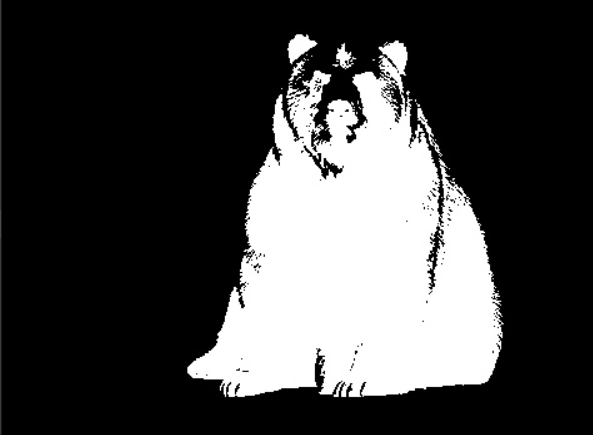

Fig.(1).

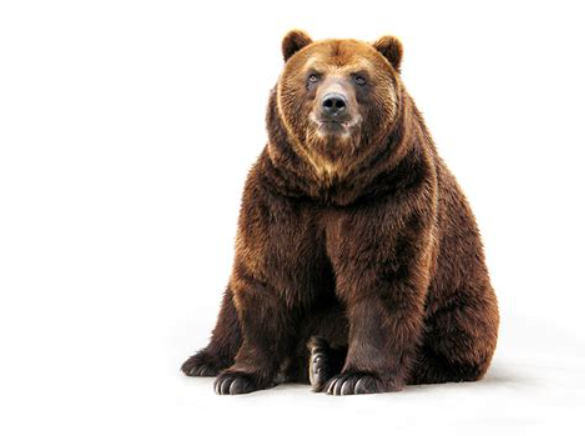

Fig.(2).


This was done to allow for simple calculation for image moments, further fine tuning will be done on the images in this case to ensure that findings can be accurate as originaly lines of symmetry showed slight deviation from their expected positions.


The following code blocks break down the steps clearly with the comments outlineing the general goal of said block at thier start.

In [4]:
# this is a set of paths that will be used later however should be defined separately for readability

# this array stores all the images that work best with inverted theasholding
img_inv = [r"Data\Raw\Snowflake.jpeg",
           r"Data\Raw\snowflake_2.jpg",
             r"Raw\Spine.jpg",
             r"Raw\Bear.jpg",
             r"Raw\Test.jpg",
             r"Raw\Bone.jpg",
             r"Raw\Bone_2.jpg",
             #r'Raw\Triangle.jpg',
             r"Data\Shape\Raw\Bear_Shape.jpg",
             r"Data\Shape\Raw\Snow_shape.jpg",
             r"Data\Shape\Raw\Bone_Shape.jpg",
             r"Data\Shape\Raw\Square_shape.png",
             r'Data\Shape\Raw\spine_shape.jpg']

# no filling to be applied to these as it damages the quality of the images
no_fill = [r"Raw\Snowflake.jpeg",
           r"Raw\snowflake_2.jpg",
           r"Data\Shape\Raw\Snow_shape.jpg"]

#this is the path of the folder which stores all the data folders
New_loc = r"C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data"

# this is the path for the shape folder path
shape_loc = r"C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Shape"

#this is the path of the code and all project related files, should be the current working directory at most times during runtime
Old_loc = r"C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs"


# changes directory to the conv folder for the sake of saving the images
os.chdir(New_loc)

# a set of file paths for where code should be stored
raw_folder = os.path.join(New_loc, "Raw")
conv_folder = os.path.join(New_loc, "Conv")

Symm_folder = os.path.join(New_loc, "Symm")
Symm_folder_Hu = os.path.join(Symm_folder, "Hu")
Symm_folder_Raw = os.path.join(Symm_folder, "Raw")

# paths for the shape data which stores all shape related images
shape_raw_folder = os.path.join(shape_loc, "Raw")
shape_conv_folder = os.path.join(shape_loc, "Conv")

To be able to perform any analysis it is key that basic threasholding is performed on the images such that binary images are created, to this end the following code block is used to go through all the files inside of the Raw folder and then creating a new binary image which is to be stored inside of the Conv folder after it has been recentered and filled.

**Recentering** is done such that when the images have symmetry investigated they are able to be rotated without being sent beyond the limits of the image.

**Filling** is done to ensure that the black spots present within the binary images are minimised, this is done as the black gaps within the object of interest can cause the lines of symmetry to be offset from where they would be for the original image of interest. Thus introducing a *systimatic error*, however filling this gap in should help reduce this error's impact.

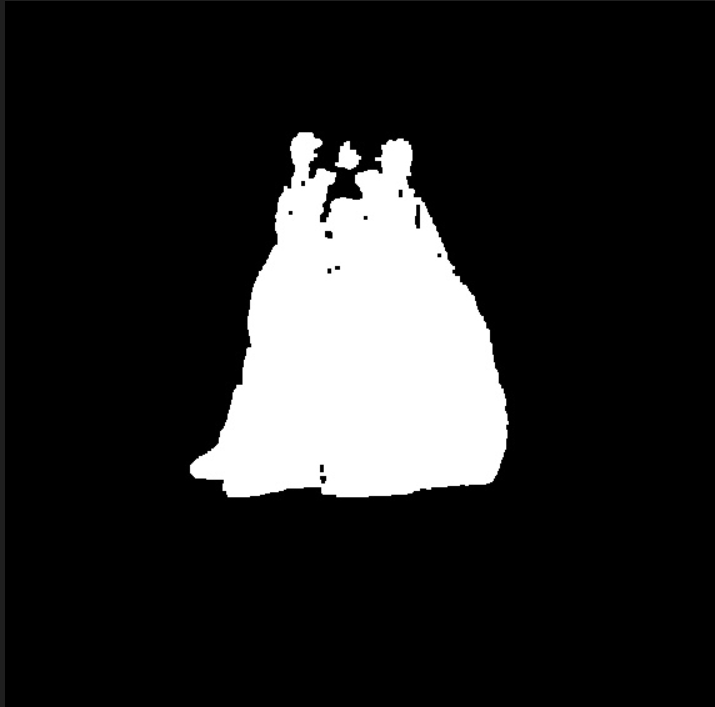

Fig.(3). filled in image after recentering

In [5]:
# Here is the code used to convert the images into binary images and then save them in the Conv folder

count = 0

for img_interest in os.scandir(raw_folder):
    count += 1
    
    if img_interest.is_file():
        filename = os.path.basename(img_interest.path)

        file_path = rf"Raw\{filename}"

        if file_path in img_inv:
            Img_Bin = B.Img_Conv(file_path, inv = True)
            print(f"{filename} has undergone inverted binary thresholding")

        else:
            Img_Bin = B.Img_Conv(file_path, inv = False)
            print(f"{file_path} has undergone standard binary thresholding")

        # if there is an error it is likely due to the image not being binarised correctly
        cx, cy = IM.Centroid(Img_Bin)
        cx, cy = int(round(cx)), int(round(cy))
        img_conv = B.recenter_binary_image(Img_Bin, (cx, cy))
        
            
            
        img_conv = B.fill_black_spots(img_conv, file_path, no_fill)
        
        
        conv_save_path = os.path.join(conv_folder, filename)
        cv.imwrite(conv_save_path, img_conv)
        print(conv_save_path)

print(f"a total of {count} files have been converted into binary files.")

Bear.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\Bear.jpg
Bone.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\Bone.jpg
Bone_2.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\Bone_2.jpg
Raw\Snowflake.jpeg has undergone standard binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\Snowflake.jpeg
Raw\snowflake_2.jpg has undergone standard binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\snowflake_2.jpg
Spine.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\Spine.jpg
Raw\square.tif has undergone standard binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv\square.tif
a total of 7 f

From the images shown, Fig.(1), it is clear that the images have black spots within them which would contribute to a *systematic error* in the final lines of symmetry.

Because of this, the lines of symmetry would be off by some amount based upon the position of these gaps. To attempt to reduce the effects of this error, the fill function from cv2 will be used to ensure that the images are filled where they should be.

This could help minimise the effects of the systematic error. However, quantifying how much it impacts the lines would be difficult as it would require lines of symmetry without this error be added to the images and then a value of how far of they are be calculated. Doing this for each and every image may be difficult.


# 6 Quantifying Symmetry

When trying to find symmetry, it was a key aim to quantify it. To do this the concept of a "symmetry score" was proposed in order to create a clear way that the method could be evaluated in a clearer fashion.

Further more, to show that the methods used is accurate, multiple methods were used. This was to provide a "success criteria" for the investigation, whether or not the methods created would be comparable to the more traditional ones used. This would also provide a way to better analyse the methods, as some may relay upon assumptions about the image used where others may not.

## 6.1 Overview of methods

One method is to consider the 2nd and 3rd order moments for the image regions. There are a number of rules which must remain true given that image an image is symmetric.

An alternative to this is to use Contours to find the symmetry of an image. This will be done by my lab partner who will perform an analysis on the images using cv2 more, this will also be used as another point of comparison and potentially a success criteria for confirmation that the method works as expected.

The most promising option for this is to find the Hu moments for each region to then compare them.

### 6.2 Outline of key details:

- calculate centroid for the image

- recentering the image with centroid at the center to prevent potential boarder cut off.

- define a vertical axis through the centroid of the image

- rotation of the image about the centroid, increments should be appropiate such that precise plots can be produced.

- calculate image moments for each half of the image defined using the centroid, the left and the right of the centroid

- calculate the symmetry score for each rotation of the image and if above a defined limit, would store that number of degrees relative to the vertical axis
    - Symmetry score calculation being different based upon the method used

- after a toatal 180 degree rotation, apply all stored degrees with their respective symmetry scores for later analysis and plotting


For both methods there must be cerification that each method works as expected. To do this, a test image with lines of symmetry that are known should be used, to do this the following will be used:

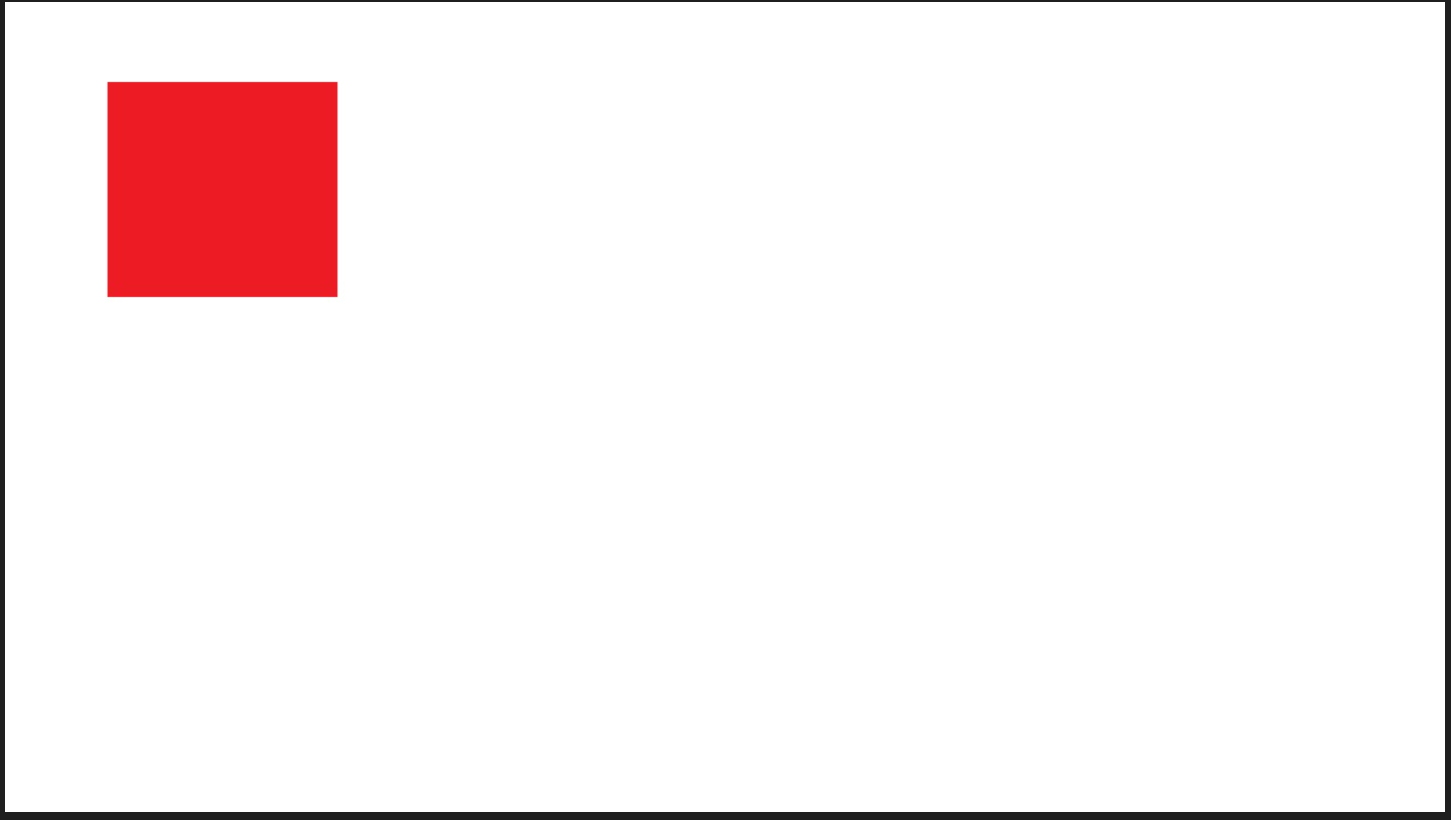

Fig.(4). Test image, a square.

This image is off centered and red to ensure that image conversion also works as expected and from that process the following is produced:


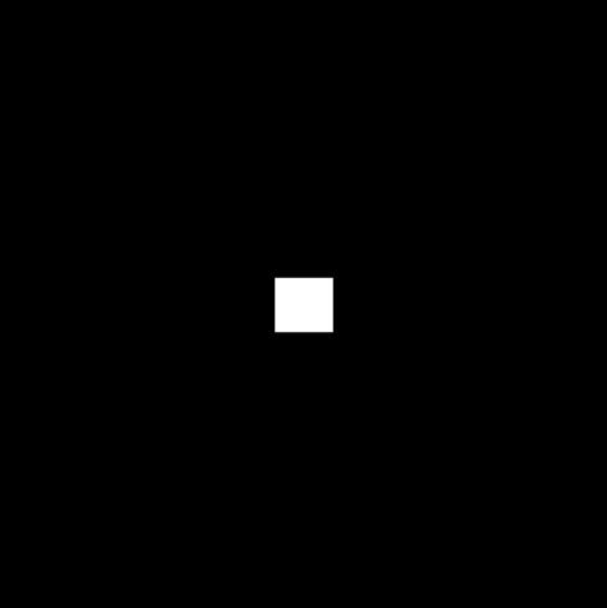

Fig.(5). Test image converted and recentered.


## 6.3 Method 1: Calculation of area and rotation of image

### 6.3.1 Key details

This method consists of calculating the Raw image moments of the segments of the image in order to then find the area, with this it will allow for a potential method of how lines of symmetry can be produced.

In order for this to work, the general steps for the method will be followed however a key addition is that the image will be "mirrored" about the centroid due to the fact these raw moments aren't translationally invariant and so any difference in position will damage the ability to calculate these image moments correctly.

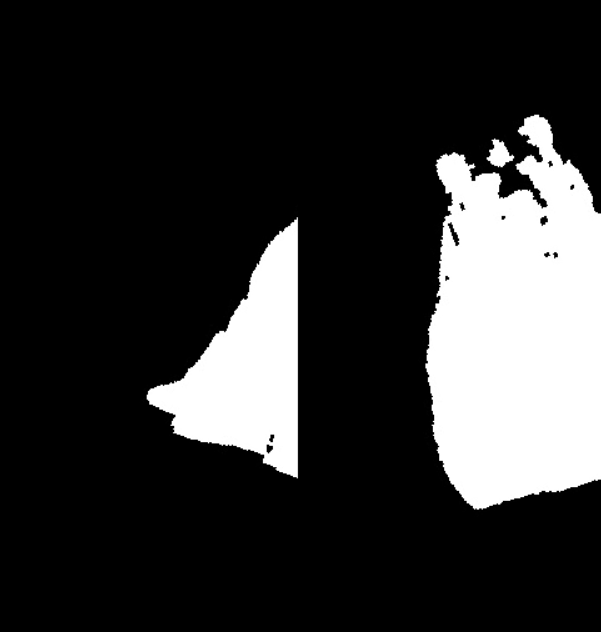

Fig.(6). image showing binary bear being mirrored through it's centroid.

Fig.(6). shows how the images would be mirrored for the sake of calcuation, then the image would be spit into two separate images about the centroid, both left and right.

In [6]:
data = {}
#file_path = r"C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv"

print("Looping has started")
count = 0
for img_interest in os.scandir(conv_folder):

    filename = os.path.basename(img_interest.path)
    img_symm = cv.imread(img_interest.path, 2)
    
    #dimension values
    height, width = img_symm.shape
    #length = max(height, width) * 2


    #centroid calculation
    cx, cy = IM.Centroid(img_symm)
    cx, cy = int(round(cx)), int(round(cy))

    #if filename == "square.tif":
    #code for finding the degrees symmetry scores and moments of interest
    degrees, scores, moments_of_interest = S.find_symmetry_binary(img_symm.copy(), centroid=(cx,cy), height = height, width = width, looping=True)

    data[f"{filename}"] = [degrees, scores, moments_of_interest]
    print(filename)
    P.plot_degrees_vs_scores(degrees = degrees, scores = scores, filename = filename)

    count += 1
    print(f"{count} number of loops completed!")


Looping has started
Bear.jpg
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Bear_Plot.jpg'
1 number of loops completed!
Bone.jpg
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Bone_Plot.jpg'
2 number of loops completed!
Bone_2.jpg
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Bone_2_Plot.jpg'
3 number of loops completed!
Snowflake.jpeg
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Snowflake_Plot.jpeg'
4 number of loops completed!
snowflake_2.jpg
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\snowflake_2_Plot.jpg'
5 number of loops completed!
Spine.jpg
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Spine_Plot.jpg'
6 number of loops completed!
square.tif
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Pl

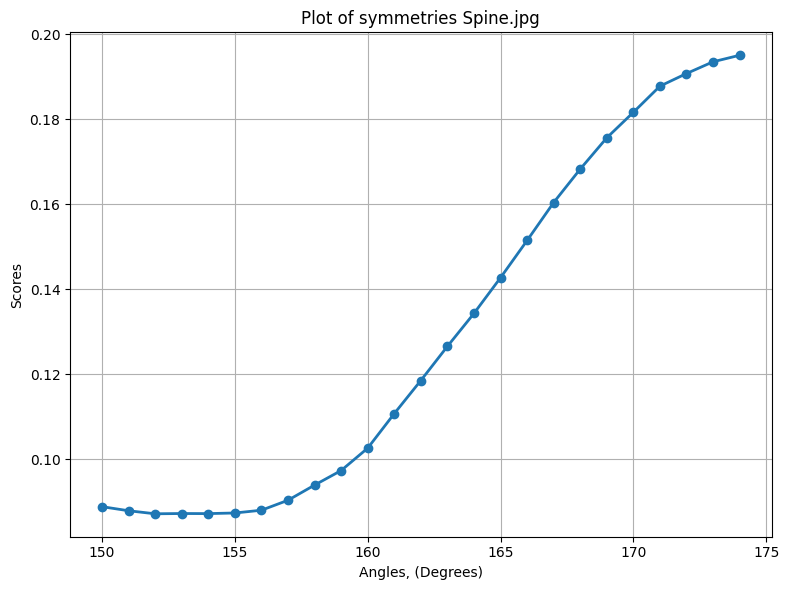

In [7]:
# Create the plot
plt.figure(figsize=(8, 6))

plt.plot(data["Spine.jpg"][0][150:175], data["Spine.jpg"][1][150:175], marker='o', linestyle='-', linewidth = 2)

plt.title(f'Plot of symmetries {"Spine.jpg"}')
plt.xlabel("Angles, (Degrees)")
plt.ylabel("Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.close()

In [8]:
symm_angles = [[0,57,129,178],
               [101],
               [0,180],
               [0,34,70,78,158],
               [13,154],
               [40,166],
               [125]]

symm_angles = [[180, 123, 51, 2],
               [79],
               [0,180],
               [180,146,110,102,22],
               [167,26],
               [140,14],
               degrees]

count = 0

for img_interest in os.scandir(conv_folder):
    
    if img_interest.is_file():
        filename = os.path.basename(img_interest.path)
        img = cv.imread(img_interest.path, 2)


        Cent = IM.Centroid(img)
        #cv.circle(img, data[filename][3], 5, (0,0,255), -1)

        if filename != "Test.jpg":
            img_symm = P.draw_all_symmetry_lines(img, centroid = Cent, angles=symm_angles[count])
        
        cv.imshow(filename, img_symm)
        cv.waitKey(0)
        cv.destroyAllWindows()
        cv.imwrite(fr"{Symm_folder_Raw}\\{filename}", img_symm)

        count += 1

In [9]:
display(data)

{'Bear.jpg': [[0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100,
   101,
   102,
   103,
   104,
   105,
   106,
   107,
   108,
   109,
   110,
   111,
   112,
   113,
   114,
   115,
   116,
   117,
   118,
   119,
   120,
   121,
   122,
   123,
   124,
   125,
   126,
   127,
   128,
   129,
   130,
   131,
   132,
   133,
   134,
   135,
   136,
  

In [10]:
symm_angles = [[0,57,129,178],
               [101],
               [0,180],
               [0,34,70,78,158],
               [13,154],
               [40,166],
               [125]]


result = [data["Bear.jpg"][1][i] for i in symm_angles[0]]
result

[np.float64(0.005421955731326146),
 np.float64(0.008483766026663264),
 np.float64(0.007762819285820626),
 np.float64(0.009929620888350237)]

In [11]:
# Bear, Bone, Bone_2, Snowflake, Snowflake_2, Spine, Square
symm_angles = [[180, 123, 51, 2],
               [79],
               [0,180],
               [180,146,110,102,22],
               [167,26],
               [140,14],
               degrees]

#table = pd.DataFrame({"Bear": symm_angles[0],
#            "Bone": symm_angles[1],
#            "Bone_2": symm_angles[2],
#            "Snowflake": symm_angles[3],
#            "Snowflake_2": symm_angles[4],
#            "Spine": symm_angles[5],
#            "Square": symm_angles[6]})

names = ["Bear", "Bone", "Bone_2", "Snowflake", "Snowflake_2", "Spine", "Square"]
lines = [len(i) for i in symm_angles]
angles_interest = [sorted(i) for i in symm_angles]
angles_interest[-1] = ["0,1,2,...,180"]

symm_scores = [[round(data["Bear.jpg"][1][i],5) for i in symm_angles[0]],
               [round(data["Bone.jpg"][1][i],5)  for i in symm_angles[1]],
               [round(data["Bone_2.jpg"][1][i],5)  for i in symm_angles[2]],
               [round(data["Snowflake.jpeg"][1][i],5)  for i in symm_angles[3]],
               [round(data["snowflake_2.jpg"][1][i],5)  for i in symm_angles[4]],
               [round(data["Spine.jpg"][1][i],5)  for i in symm_angles[5]],
               [round(data["square.tif"][1][i],5)  for i in symm_angles[6]]]
               

table = pd.DataFrame({"Image name": ["Bear", "Bone", "Bone_2", "Snowflake", "Snowflake_2", "Spine", "Square"],
            "Number of symmetry lines": lines,
            "Angles of interest": angles_interest,
            "Symmetry scores": symm_scores})

table

,Image name,Number of symmetry lines,Angles of interest,Symmetry scores
0,Bear,4,"[2, 51, 123, 180]","[0.00551, 0.0465, 0.03001, 0.00974]"
1,Bone,1,[79],[0.0901]
2,Bone_2,2,"[0, 180]","[0.03845, 0.03845]"
3,Snowflake,5,"[22, 102, 110, 146, 180]","[0.05617, 0.00472, 0.05701, 0.03096, 0.03255]"
4,Snowflake_2,2,"[26, 167]","[0.00075, 0.01454]"
5,Spine,2,"[14, 140]","[0.09629, 0.00168]"
6,Square,181,"[0,1,2,...,180]","[0.0, 4e-05, 9e-05, 0.00013, 0.00019, 0.00024,..."


### 6.3.2 Analysis of findings, Method 1:

### 6.3.2.1 Overview

From this method, a number of graphs were produced and insights from these graphs can be gained by through either consideration of the minima for the graphs and/or looking at scores below some threshold.

For the first method it would be expected to be values below some threashold which would be considered. Then the minima chosen.


### 6.3.2.2 Figures

Although a number of images were used for this conversion to ensure variation in findings. However for the sake of brevity, only some images will be shown here.

#### 6.3.2.3 Test image

Test image shows that the method behaves about as expected as the area of a square through the centroid of each half should be the same for all angles. This is shown as all the values of symmetry score are very low, all being below 8e-4. Due to this it can be said that the test for the methods validity was passed.

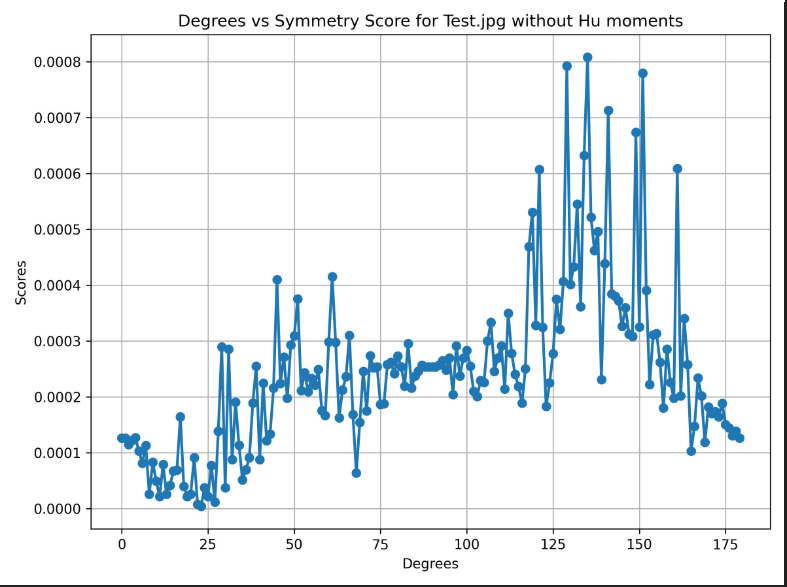

Fig.(7). test image found with my work

For this to pass the test it would be expected that the points don't siginicantly deviate from zero, this is clearly shown. As such it can be considered passed.

For the cv2 calculations, the following plot was produced which shows clear similarities and so was also accepted.

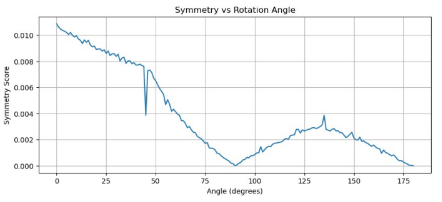

Fig.(8). work from lab partner


#### 6.3.2.4 Other images

If there are any insights or any key details that must be stated, then it will be said under the picture for which it pertains. Otherwise the plots will simplt be shown and an overview will be stated after the fact.

For the bear image the following graph was produced, which showed a number of minima which could be considered lines of symmetry which is not expected, however may be explained as a biproduct of how simplistic a measure of symmetry finding this is.

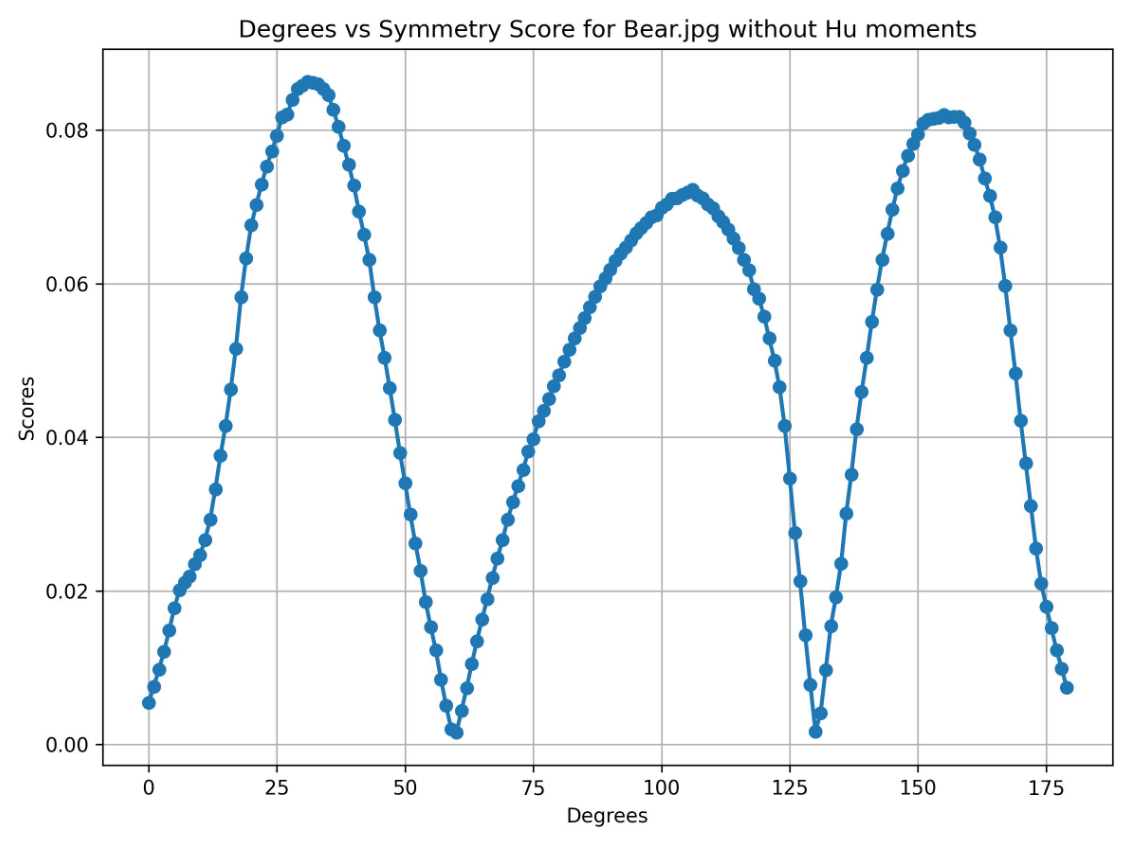

Fig.(9). method one plot for bear

From this it can be argued that the findings from this experiment may have some restrictions on if this method works effectively or not. This is because the only line of symmetry which should be shown is the one near

For zero degrees from the vertical axis.

For the bone image, it somewhat shows the expected behaviour as although it would be expected to show vertical symmetry it does show clear horizontal symmetry.

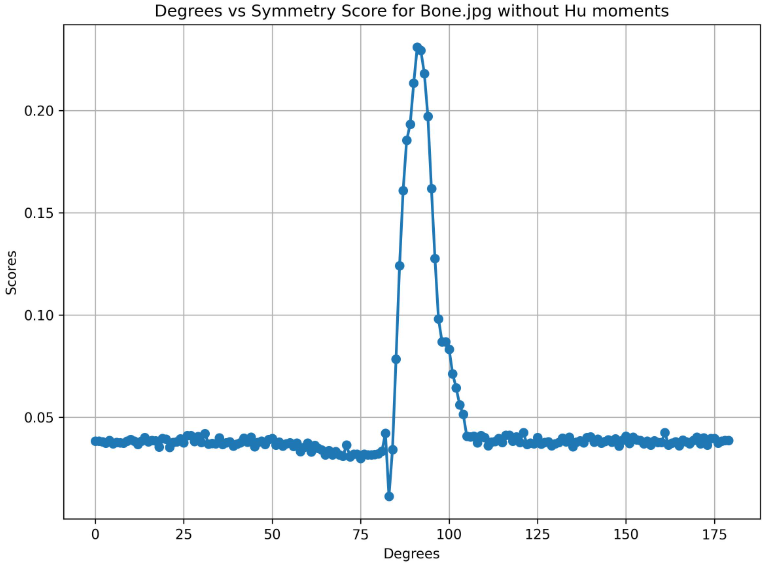

Fig.(10). method one plot for bone

however this is strange as this would mean the symmetry is only shown when graph peaks for the bone. This is an unexpected finding

## 6.4 Method 2: Calculation of Hu moments

### 6.4.1 Outline:

During this section, the Hu moments will be investigated into to find out how they differ in both requirments and performance when compared to Method 1. Due to the fact they are the standard method used for symmetry quantification, it is expected that the values found using this method would be more accurate then method 1 for quantifying symmetry.

Hu moments are can be used to quantify symmetry as the value will be very low, close to zero, when symmetric and very large when asymmetric.

During this section work will be done.

WE ONLY TAKE UP TO MOMENT 5 AS 6 AND 7 ARE SENSITIVE TO NOISE AND REAL IMAGES HAVE A LOT OF NOISE

In [12]:
data = {}
keep = []
#file_path = r"C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Conv"

print("Looping has started")
count = 0
for img_interest in os.scandir(conv_folder):

    filename = os.path.basename(img_interest.path)
    img_symm = cv.imread(img_interest.path, 2)
    
    #dimension values
    height, width = img_symm.shape
    #length = max(height, width) * 2


    #centroid calculation
    cx, cy = IM.Centroid(img_symm)
    cx, cy = int(round(cx)), int(round(cy))

    #code for finding the degrees symmetry scores and moments of interest
    #if filename == "square.tif":
    degrees, scores, moments_of_interest = S.find_symmetry_binary(img_symm.copy(),centroid = (cx,cy), height = height, width = width, looping=True, Hu=True)
     # here we want the code to only take the specific scores which are useful, for this we will only look at 1-5 as 6 and 7 seem sensitive to noise which real images have a lot of!
    score_av = np.array([[x[0] for x in scores], [x[1] for x in scores], [x[2] for x in scores], [x[3] for x in scores]]).mean(axis=0)

    data[f"{filename}"] = [degrees,
                            score_av,
                            S.find_local_minima(score_av),
                            (cy,cx),
                            moments_of_interest]


    P.plot_degrees_vs_scores(degrees = degrees, scores = score_av, filename = filename, Hu = True)

    degrees_of_interest = []
    scores_of_interest = []

    for i in data[f"{filename}"][2]:
        degrees_of_interest.append(degrees[i])
        scores_of_interest.append(score_av[i])

    keep.append([degrees_of_interest, scores_of_interest, filename])

    count += 1
    print(f"{count} number of loops completed!")



Looping has started
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Bear_Hu_Plot.jpg'
1 number of loops completed!
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Bone_Hu_Plot.jpg'
2 number of loops completed!
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Bone_2_Hu_Plot.jpg'
3 number of loops completed!
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Snowflake_Hu_Plot.jpeg'
4 number of loops completed!
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\snowflake_2_Hu_Plot.jpg'
5 number of loops completed!
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\Spine_Hu_Plot.jpg'
6 number of loops completed!
Plot saved as 'C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Plots\square_Hu_Plot.tif'
7 number of loops completed!


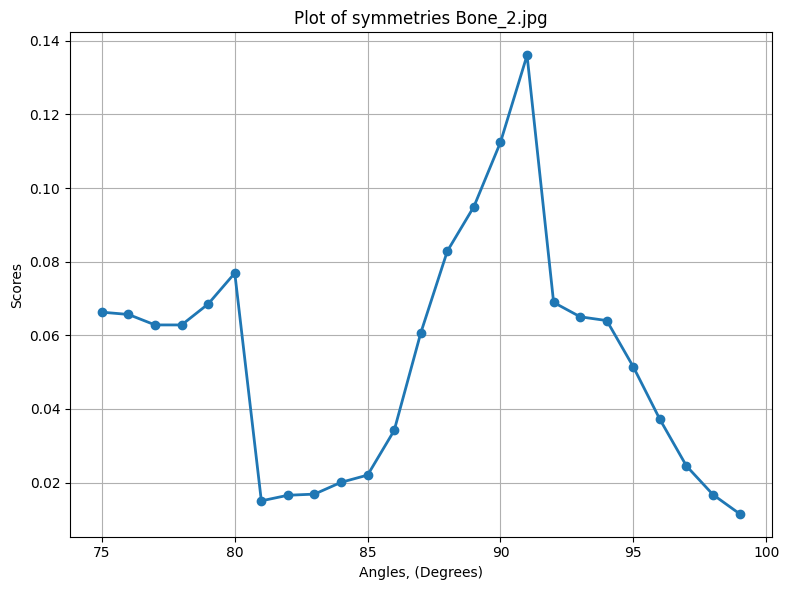

In [13]:
# Create the plot
plt.figure(figsize=(8, 6))

plt.plot(data["Bone_2.jpg"][0][75:100], data["Bone_2.jpg"][1][75:100], marker='o', linestyle='-', linewidth = 2)

plt.title(f'Plot of symmetries {"Bone_2.jpg"}')
plt.xlabel("Angles, (Degrees)")
plt.ylabel("Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.close()

In [14]:
symm_angles = [[0,65,125],
               [0,77,97],
               [0,100,87],
               [1,60,96,118,140],
               [31,76,149,181],
               [9,93],
               [0,45,90,135]]

symm_angles = [[180,115,55],
               [180,103,83],
               [180,80,93],
               [179,120,84,62,40],
               [140,104,31,0],
               [171,87],
               [180,135,90,45]]
count = 0

for img_interest in os.scandir(conv_folder):
    
    if img_interest.is_file():
        filename = os.path.basename(img_interest.path)
        img = cv.imread(img_interest.path, 2)


        Cent = IM.Centroid(img)
        #cv.circle(img, data[filename][3], 5, (0,0,255), -1)

        if filename != "Test.jpg":
            img_symm = P.draw_all_symmetry_lines(img, centroid = Cent, angles = symm_angles[count])
        
        cv.imshow(filename, img_symm)
        cv.waitKey(0)
        cv.destroyAllWindows()
        cv.imwrite(fr"{Symm_folder_Hu}\\{filename}", img_symm)

        count += 1

In [15]:
# Bear, Bone, Bone_2, Snowflake, Snowflake_2, Spine, Square

names = ["Bear", "Bone", "Bone_2", "Snowflake", "Snowflake_2", "Spine", "Square"]
lines = [len(i) for i in symm_angles]
angles_interest = [sorted(i) for i in symm_angles]

symm_scores = [[round(data["Bear.jpg"][1][i],5) for i in symm_angles[0]],
               [round(data["Bone.jpg"][1][i],5)  for i in symm_angles[1]],
               [round(data["Bone_2.jpg"][1][i],5)  for i in symm_angles[2]],
               [round(data["Snowflake.jpeg"][1][i],5)  for i in symm_angles[3]],
               [round(data["snowflake_2.jpg"][1][i],5)  for i in symm_angles[4]],
               [round(data["Spine.jpg"][1][i],5)  for i in symm_angles[5]],
               [round(data["square.tif"][1][i],5)  for i in symm_angles[6]]]
               

table = pd.DataFrame({"Image name": ["Bear", "Bone", "Bone_2", "Snowflake", "Snowflake_2", "Spine", "Square"],
            "Number of symmetry lines": lines,
            "Angles of interest": angles_interest,
            "Symmetry scores": symm_scores})

table

,Image name,Number of symmetry lines,Angles of interest,Symmetry scores
0,Bear,3,"[55, 115, 180]","[0.00443, 0.02054, 0.01673]"
1,Bone,3,"[83, 103, 180]","[0.00489, 0.00921, 0.04135]"
2,Bone_2,3,"[80, 93, 180]","[0.02709, 0.0769, 0.06503]"
3,Snowflake,5,"[40, 62, 84, 120, 179]","[0.0133, 0.00716, 0.01775, 0.01259, 0.01425]"
4,Snowflake_2,4,"[0, 31, 104, 140]","[0.01289, 0.01871, 0.00487, 0.01039]"
5,Spine,2,"[87, 171]","[0.05158, 0.02697]"
6,Square,4,"[45, 90, 135, 180]","[0.00039, 2e-05, 0.00039, 0.0]"


### 6.4.2 Analysis of findings: Method 2

### 6.4.2.1 Overview

From thsi method, graphs were also produced, from them insights can also be gained, most of which are similar to those gained for the first method.

### 6.4.2.2 Figures

#### 6.4.2.3 Test image

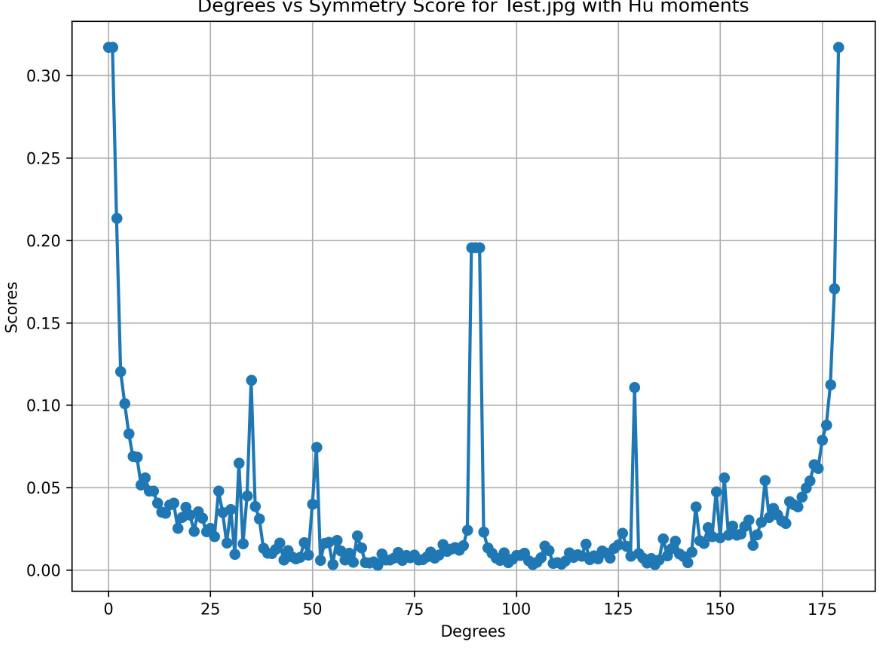

Fig.(11). data for test image

clearly this image show odd behaviour also, this is due to the fact that the data is expected to have minima at the start of the graph near 0, however if we look at the peaks of the image, it does show the lines of symmetry as expected. This will be accepted as passing criteria.

For the graph produced from my lab partner a similar graph was found.

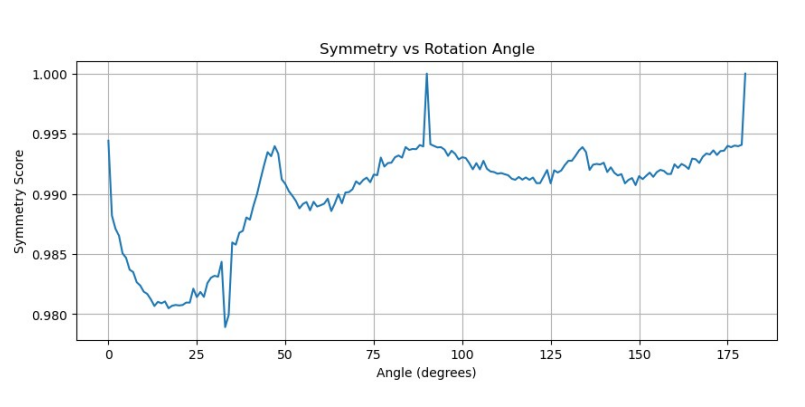

Fig.(12). data from lab partner

it is important to look into why this is the case.

#### 6.4.2.4 Other images

The bear image shows a large amount of similarity to the graph found from method 1, this shows that method 1 has some level of validity.

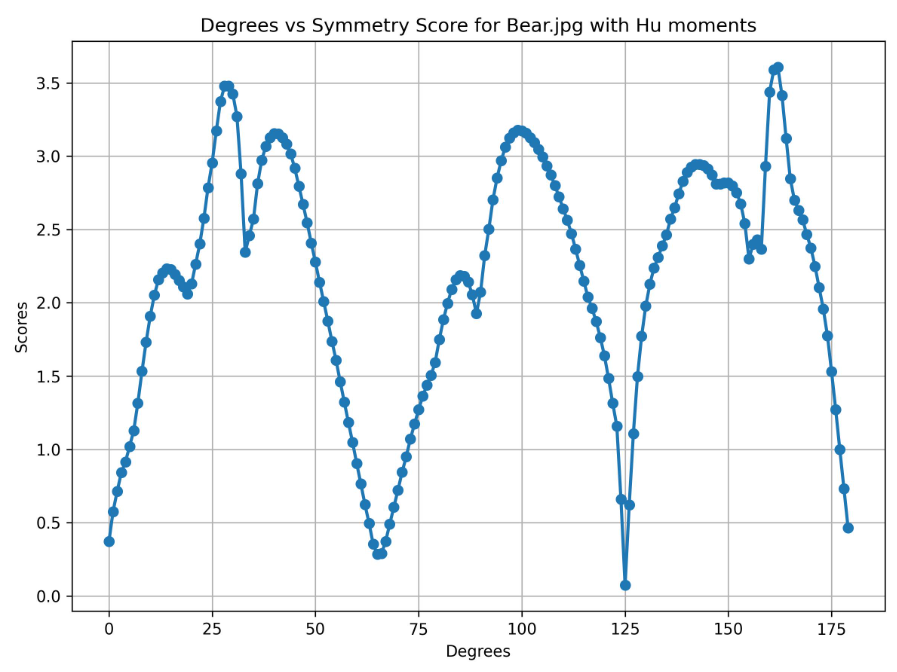

Fig.(13). data for the Hu moments for the bear image

For the bone image, the graph data shows that there's a similar trend to that shown in method 1 once again.

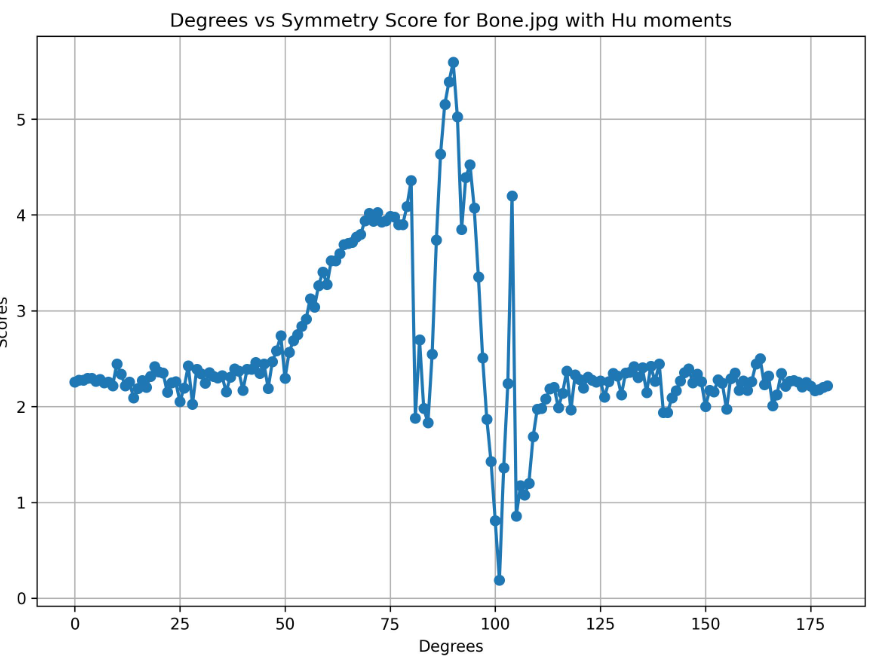

Fig.(14). data for the Hu moments for the bone image

# 7. Quantifying Shape

Although the main focus of this investigation is to look into symmetry it is important to describe the shape of our images.

To do this, the binary images had the second order central moments taken as these would provide insight into the a number of shape descriptors, these will then be stored in a table which can show all of these features.

In addition, the objects will be classified using a set of shape images. Images with known types and then their Hu moments will be found. If a sample image shows similar values, and no other values are more similar, then that object type will be saved as it's class.

In [16]:
# A data frame which will store all data related to feature

feature_data = {
    "Image name": [],
    "Shape type": [],

    #"Centroid x position": [],
    #"Centroid y position": [],

    "Skewness in x": [],
    "Skewness in y": [],

    "Spread": [],
    "Orientation": [],
    "Eccentricity": []
}


Hu_data = {
    "Image name": [],
    "I_1": [],
    "I_2": [],
    "I_3": [],
    "I_4": [],
    "I_5": [],
    "I_6": [],
    "I_7": []
}


#creates tha dataframes
df = pd.DataFrame(feature_data)
df_Hu = pd.DataFrame(Hu_data)


In [17]:
#code that converts the images in the raw shapes folder into binary then stores them in the conv folder
os.chdir(Old_loc)
print("Looping has started")
count = 0
for img_interest in os.scandir(shape_raw_folder):

    filename = os.path.basename(img_interest.path)
    img = cv.imread(img_interest.path, 2)

    file_path = rf"Data\Shape\Raw\{filename}"

    if file_path in img_inv:
            Img_Bin = B.Img_Conv(file_path, inv = True)
            print(f"{filename} has undergone inverted binary thresholding")

    else:
        Img_Bin = B.Img_Conv(file_path, inv = False)
        print(f"{file_path} has undergone standard binary thresholding")

    #centroid calculation and basic convertion
    cx, cy = IM.Centroid(img)
    cx, cy = int(round(cx)), int(round(cy))
    img_conv = B.recenter_binary_image(Img_Bin, (cx, cy))
    img_conv = B.fill_black_spots(img_conv, file_path, no_fill)

    conv_save_path = os.path.join(shape_conv_folder, filename)
    
    cv.imwrite(conv_save_path, img_conv)
    print(conv_save_path)
    
    count += 1
print(f"{count} number of loops completed!")

Looping has started
Bear_Shape.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Shape\Conv\Bear_Shape.jpg
Bone_Shape.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Shape\Conv\Bone_Shape.jpg
Snow_shape.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Shape\Conv\Snow_shape.jpg
spine_shape.jpg has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Shape\Conv\spine_shape.jpg
Square_shape.png has undergone inverted binary thresholding
C:\Users\alloh\OneDrive\Desktop\coding\workspace\Term One Labs\Data\Shape\Conv\Square_shape.png
5 number of loops completed!


These images stored in the shape folder, will have their Hu moments stored for later comparison between these and other images

Clearly the classification didn't work as expected and so it would make the most sense to re-evaluate and create code that classifies based upon Hu moments and the feature data as a combination of all these features would produce a working classification method

In [18]:
# Code that works to calculate the features for the set of test shapes

count = 0
shape_data = []

for img_interest in os.scandir(shape_conv_folder):

    filename = os.path.basename(img_interest.path)
    image = cv.imread(img_interest.path, 2)
    
    #dimension values
    height, width = image.shape

    #centroid calculation
    cx, cy = IM.Centroid(image)
    cx, cy = int(round(cx)), int(round(cy))
    centroid = (cx, cy)

    #Central moments required for feature investigation
    Mu_00 = IM.Central_Order_Moments(img = image, p=0, q=0, x_cent=cx, y_cent=cy)

    Mu_11 = IM.Central_Order_Moments(img = image, p=1, q=1, x_cent=cx, y_cent=cy)
    Mu_02 = IM.Central_Order_Moments(img = image, p=0, q=2, x_cent=cx, y_cent=cy)
    Mu_20 = IM.Central_Order_Moments(img = image, p=2, q=0, x_cent=cx, y_cent=cy)
    
    Mu_30 = IM.Central_Order_Moments(img = image, p=3, q=0, x_cent=cx, y_cent=cy)
    Mu_03 = IM.Central_Order_Moments(img = image, p=0, q=3, x_cent=cx, y_cent=cy)


    # the calculations for the features of interest
    centroid = (cx, cy)
    theta = S.orientation(Mu_11=Mu_11, Mu_20=Mu_20, Mu_02=Mu_02)
    e = S.eccentricity(Mu_00=Mu_00, Mu_20=Mu_20, Mu_02=Mu_02)
    spread = S.Spread(Mu_00=Mu_00, Mu_20=Mu_20, Mu_02=Mu_02)
    skewness = S.Skewness(Mu_30 = Mu_30, Mu_03 = Mu_03, Mu_20 = Mu_20, Mu_02 = Mu_02)
    
    # Hu moments calculations as needed
    Hu = IM.Hu_Moments(img=image ,x_cent=cx, y_cent=cy)


    shape_data.append({"Name": filename,
                        "Hu Moment": Hu,
                        #"Centroid": centroid,
                        "Spread": spread,
                        "Skewness": skewness,
                        "Orientation": theta,
                        "Eccentricity": e})

    count += 1
    print(f"{count} number of loops completed!")

1 number of loops completed!
2 number of loops completed!
3 number of loops completed!
4 number of loops completed!
5 number of loops completed!


THIS CODE DOESN'T WORK YET FIX THE DIFFERENCE CALCULATION TO ALLOW FOR ACCURATE CLASSIFICATION

In [19]:
print("Looping has started")
count = 0

for img_interest in os.scandir(conv_folder):

    filename = os.path.basename(img_interest.path)
    image = cv.imread(img_interest.path, 2)

    # Get image dimensions
    height, width = image.shape

    # Compute centroid
    cx, cy = IM.Centroid(image)
    cx, cy = int(round(cx)), int(round(cy))

    # Central moments
    Mu_00 = IM.Central_Order_Moments(image, 0, 0, cx, cy)
    Mu_11 = IM.Central_Order_Moments(image, 1, 1, cx, cy)
    Mu_02 = IM.Central_Order_Moments(image, 0, 2, cx, cy)
    Mu_20 = IM.Central_Order_Moments(image, 2, 0, cx, cy)
    Mu_30 = IM.Central_Order_Moments(image, 3, 0, cx, cy)
    Mu_03 = IM.Central_Order_Moments(image, 0, 3, cx, cy)

    # Feature values
    centroid = (cx, cy)
    theta = S.orientation(Mu_11, Mu_20, Mu_02)
    e = S.eccentricity(Mu_00, Mu_20, Mu_02)
    spread = S.Spread(Mu_00, Mu_20, Mu_02)
    skewness = S.Skewness(Mu_30, Mu_03, Mu_20, Mu_02)

    # Hu moments
    Hu = IM.Hu_Moments(image, cx, cy)

    # Feature vector for comparison
    feature_vec = np.array([
        #cx, cy, 
        spread,
        skewness[0], skewness[1],
        theta, e
    ])

    # Classification tracking variables
    group_curr_Hu = ""
    group_curr_feature = ""
    change = False
    best_diff = 1e-15
    give = 5
    offset = 3e-10

    # Compare to known shapes
    for group in shape_data:

        # Hu moments diff
        Hu_diff = np.sum(
            np.abs(group["Hu Moment"][:-2] - Hu[:-2]) / #we only take up to the 5th moment as last two are too sensitive due to noise
            (np.abs(Hu[:-2]) + np.abs(group["Hu Moment"][:-2]) + offset)
        )

        # Feature vector diff
        group_features = np.array([
            #group["Centroid"][0], group["Centroid"][1],
            group["Spread"],
            group["Skewness"][0], group["Skewness"][1],
            group["Orientation"], group["Eccentricity"]
        ])

        feature_diff = np.sum(
            (np.abs(group_features) - np.abs(feature_vec)) /
              (np.sum(np.abs(group_features)) + np.sum(np.abs(feature_vec)) + offset)
            )

        # HU match logic
        if Hu_diff < give:
            if change:
                if Hu_diff < best_diff:
                    group_curr_Hu = group["Name"]
                    best_diff = Hu_diff
            else:
                group_curr_Hu = group["Name"]
                best_diff = Hu_diff
                change = True

        # Feature match logic
        if feature_diff < give:
            if change:
                if feature_diff < best_diff:
                    group_curr_feature = group["Name"]
                    best_diff = feature_diff
            else:
                group_curr_feature = group["Name"]
                best_diff = feature_diff
                change = True

    # Extract base filename (without extension)
    name = filename.split(".")[0]

    # Extract label up to underscore
    final_shape_label = group_curr_feature.split("_")[0]

    # Dataframes for normal features
    new_df = pd.DataFrame({
        "Image name": name,
        "Shape type": final_shape_label,
        #"Centroid x position": [centroid[0]],
        #"Centroid y position": [centroid[1]],
        "Skewness in x": [skewness[0]],
        "Skewness in y": [skewness[1]],
        "Spread": spread,
        "Orientation": theta,
        "Eccentricity": e
    })

    # Extract label up to underscore
    final_shape_label = group_curr_Hu.split("_")[0]

    # Dataframes for Hu
    new_Hu_df = pd.DataFrame({
        "Image name": name,
        "Shape type": final_shape_label,
        "I_1": [Hu[0]],
        "I_2": [Hu[1]],
        "I_3": [Hu[2]],
        "I_4": [Hu[3]],
        "I_5": [Hu[4]],
        "I_6": [Hu[5]],
        "I_7": [Hu[6]]
    })

    # Save results
    df = pd.concat([df, new_df], ignore_index=True)
    df_Hu = pd.concat([df_Hu, new_Hu_df], ignore_index=True)

    count += 1
    print(f"{count} number of loops completed!")


Looping has started
1 number of loops completed!
2 number of loops completed!
3 number of loops completed!
4 number of loops completed!
5 number of loops completed!
6 number of loops completed!
7 number of loops completed!


In [20]:
display(df_Hu)

,Image name,I_1,I_2,I_3,I_4,I_5,I_6,I_7,Shape type
0,Bear,0.000716,3.181192e-08,9.698744e-11,2.338827e-12,6.783561e-24,1.927309e-16,3.456596e-23,Bear
1,Bone,0.004526,1.956912e-05,4.984785e-11,2.410682e-11,8.267133e-22,1.012675e-13,1.220015e-22,Bear
2,Bone_2,0.016498,2.598999e-04,2.587316e-08,2.981509e-08,8.280552e-16,4.778230e-10,-7.879276e-18,Bear
3,Snowflake,0.001677,1.893518e-08,3.980096e-11,3.158929e-12,2.995033e-23,-3.907040e-16,1.891032e-23,Bear
4,snowflake_2,0.001924,1.191372e-08,2.559282e-11,3.044170e-11,4.282437e-22,-2.289472e-15,7.338848e-22,Bear
5,Spine,0.001327,4.546365e-07,3.575146e-10,1.629913e-10,2.176567e-20,9.987760e-14,3.277673e-20,Bear
6,square,0.000654,1.768214e-16,2.351268e-24,2.272205e-14,5.251970e-33,3.021446e-22,0.000000e+00,Square


In [ ]:
# First and last column from df_Hu
first_col = df_Hu.columns[0]
last_col = df_Hu.columns[-1]

# Middle columns: all columns in df that are not first_col or last_col
middle_cols = [col for col in df_Hu.columns if col not in [first_col, last_col]]

# Combine
new_order = [first_col, last_col] + middle_cols

# Reorder df
df_reordered = df_Hu[new_order]

df_reordered

,Image name,Shape type,I_1,I_2,I_3,I_4,I_5,I_6,I_7
0,Bear,Bear,0.000716,3.181192e-08,9.698744e-11,2.338827e-12,6.783561e-24,1.927309e-16,3.456596e-23
1,Bone,Bear,0.004526,1.956912e-05,4.984785e-11,2.410682e-11,8.267133e-22,1.012675e-13,1.220015e-22
2,Bone_2,Bear,0.016498,2.598999e-04,2.587316e-08,2.981509e-08,8.280552e-16,4.778230e-10,-7.879276e-18
3,Snowflake,Bear,0.001677,1.893518e-08,3.980096e-11,3.158929e-12,2.995033e-23,-3.907040e-16,1.891032e-23
4,snowflake_2,Bear,0.001924,1.191372e-08,2.559282e-11,3.044170e-11,4.282437e-22,-2.289472e-15,7.338848e-22
5,Spine,Bear,0.001327,4.546365e-07,3.575146e-10,1.629913e-10,2.176567e-20,9.987760e-14,3.277673e-20
6,square,Square,0.000654,1.768214e-16,2.351268e-24,2.272205e-14,5.251970e-33,3.021446e-22,0.000000e+00


In [22]:
display(df)

,Image name,Shape type,Skewness in x,Skewness in y,Spread,Orientation,Eccentricity
0,Bear,,4.447009e-07,-0.000103,0.601510,0.004598,0.999845
1,Bone,Square,-1.679741e-05,0.000131,79.132186,0.034449,0.999902
2,Bone_2,Square,9.267455e-05,0.000188,76.399585,-0.039475,0.999960
3,Snowflake,Square,1.993008e-06,0.000090,1.179269,-0.009991,0.999752
4,snowflake_2,Square,-3.921397e-06,0.000065,1.011846,0.734904,0.999831
5,Spine,Square,-9.595002e-05,-0.000084,0.337100,-0.110129,0.999946
6,square,Bone,-2.206686e-06,-0.000002,1.000081,0.785398,0.999959


# 8 Handling error

For this method, it was important that the image already didn't have large black spots within it as it can contribute to systematic error in the degrees. This error would be difficult to quantify, so simply finding better images for this method to work may be requied. In addition to this, through the previously used methods of error minimisation, it has been reduced as much as possible.


# 8.1 Key Sources of error

## 8.1.1 Floating-point rounding errors

Due to the size of some of the values calculated using the image moments, there may be errors related to the precision of the numbers used, this can't be directly minimised in python however in C they potentially could through the use of longs longs as they store variables with a larger number of bits compared to floats used in python*.

## 8.1.2 Gaps in binary image

A systematic error is introduced through the threasholding of images. This would be difficult to quantify however may be minimised as the images under went filling in order to reduce these gaps.

the method used to fill these gaps is done by specifying a kernal size for which it will look for and then fill it. 

## 8.1.3 Overfilling

An issue with filling is that it can cause overfilling which would introduce systematic error into the image in a similar way as with the gaps. This may be difficult to handle as it seems to be a case by case issue of measuring the filled and non-filled results and investigating if they are less or more accurate to the expected values for degrees.

However this may not be the case as potentially images with fine details such as a snowflake may need to not undergo filling as it may be more likely to damage these small details. Whereas images without these details could undergo this wouth much issue.

To classify these images, it is possible to calculate Hu moments and measure how they fluctuate. Doing this will allow for finding how many fine details an object has.

However an issue with this is that it assumes the object is binary already. This would be problematic as if the gaps are large enough, then the Hu moments wouldn't be accurate. Due to this, it is likely an inaccurate method for solving the problem as if the gaps are an issue this method for checking if it's needed wouldn't work and if they did work then the gaps wouldn't be an issue.

As such the best that can be done is to try to check by eye which images fill the gaps best without damaging the fine details of each image too greatly. Or by choosing a different amout of filling image to image.


From the data from the feature table, it can be stated that this assumption about the snowflakes having too many small details is likely correct and as such filling is likely not the correct choice for these objects as they are classified as being squares rather than snowflakes as expected.

## 8.1.4 General errors in code both in code an method

During run time, a large number of errors will be encountered, to ensure that these are fixed or better understood a large number of checks will be put into place.

One such check used, when the symmetry score was a 1 when symmetric and only symmetric values were taken. Creating a plot of findings to better understand how data should be interpreted. As the following incorrect plot was displayed:

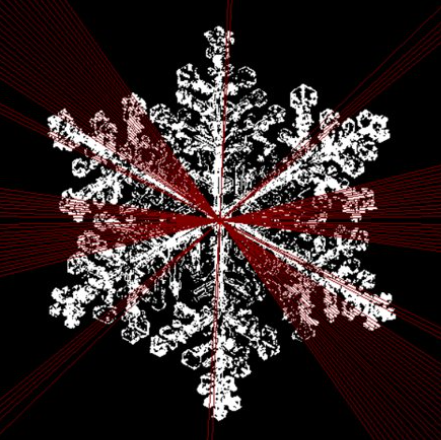

Fig.(15). Snowflake with lines of symmetry being 55

Why was wrong was unclear however the following graph was used to provide insight into why it may be wrong.

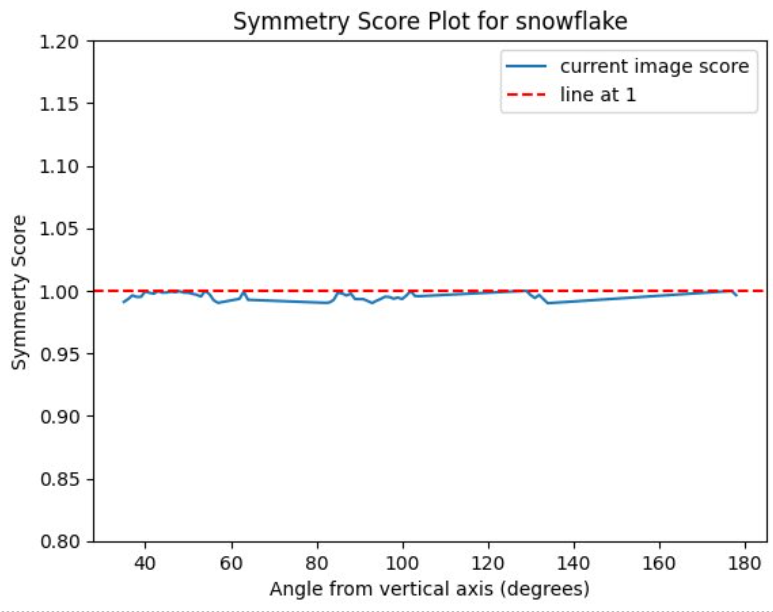

Fig.(16). Plot of symmetry score for snowflake

If this plot is correct, then it can be said that error is likely both a biproduct of the limit used not being high enough to only capture the correct lines of symmetry. As well as this, it is likely due to an error related to the gaps in the image and so filling the images is clearly important. This isn't definitive proof however it provides insight into next steps.

# 9 Bibliography

i. Research Papers

- [1] Zhang, Y., 2015. Pathological brain detection based on wavelet entropy and Hu moment invariants. Bio-Medical Materials and Engineering, 26, pp.1283–1290. doi:10.3233/BME-151426. PMID: 26405888.

- [2] Thomas, J.C., Natarajan, A.R. and Van der Ven, A., 2021. Comparing crystal structures with symmetry and geometry. npj Computational Materials, 7, p.164. doi:10.1038/s41524-021-00627-0.

- [3] Underground Mathematics, n.d. Symmetry | Thinking about Geometry. [online] Available at: https://undergroundmathematics.org
 [Accessed 12 Nov. 2025].

- [4] Anghelache, N., Moldovanu, S. and Moraru, L., 2022. Image moment-based features for mass detection in breast US images via machine learning and neural network classification models. Inventions, 7(2), p.42. doi:10.3390/inventions7020042.

- [5] Erbo, L. and Hua, L., 2017. Reflection invariant and symmetry detection. arXiv preprint, arXiv:1705.10768. Available at: https://arxiv.org/pdf/1705.10768
.

- [6] Hassan, M.F., Adam, T., Yin, M. and Paramesran, R., 2022. Effect of image denoising on geometric moments in image applications. The Journal of Analysis, 31, pp.1783–1803. doi:10.1007/s41478-022-00534-7.

- [7] Gibicar, A., Vovk, U. and Pernuš, F., 2021. Automated midline estimation for symmetry analysis of cerebral hemispheres in FLAIR MRI. Frontiers in Aging Neuroscience, 13, p.644137. doi:10.3389/fnagi.2021.644137.

- [8] Flusser, J. and Suk, T., 2005. Moment invariants for recognizing symmetric objects. In: Lecture Notes in Computer Science (LNCS), vol. 3691, pp.9–16. Springer. doi:10.1007/11556121_2.